In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# plt.rcParams.update({
#     "text.usetex": True,    # 使用LaTeX渲染所有文字
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],    # LaTeX默认字体
#     "font.size": 12,        # 默认字体大小
#     "axes.labelsize": 12,   # 轴标签字体大小
#     "legend.fontsize": 12   # 图例字体大小
# })

In [16]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,        # 默认字体大小
    "axes.labelsize": 8,   # 轴标签字体大小
    "legend.fontsize": 8,  # 图例字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

In [17]:
def parse_history_file(filename):
    headers = []
    data = []
    
    with open(filename, 'r') as f:
        for line in f:
            if not line.strip():
                continue
                
            # 处理注释行中的列名
            if line.startswith('# ['):
                # 先用']'分割行,这样可以分开每个列定义
                parts = line.strip('# \n').split(']')
                for part in parts:
                    if '=' in part:
                        # 提取等号后面的名称
                        header = part.split('=')[1].strip()
                        # 移除开头的'['(如果存在)
                        if header.startswith('['):
                            header = header[1:]
                        # 移除方括号及其中的数字
                        header = header.split('[')[0].strip()
                        if header:  # 确保不是空字符串
                            headers.append(header)
            
            # 处理数据行
            elif not line.startswith('#'):
                row_data = [float(x) for x in line.split()]
                data.append(row_data)
    
    # 将数据转换为字典格式
    result = {}
    for i, header in enumerate(headers):
        result[header] = [row[i] for row in data]
    
    return result

In [18]:
a05e00_3d = "/home/zhangzelin/projects/kharma-data-sync/20241216_cuda_sane_a05000_288-192-128_6-12_rout1000_min020_gamma13/torus.hst"
a09e00_3d = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_sane_a09375_288-192-128_6-12_rout1000_min020_gamma13/torus.hst"
a05ef5_3d = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a05000_eta-05_288-192-128_6-12_rout1000_min020_gamma13/kz_torus.hst"
a05ez5_3d = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a05000_eta+05_288-192-128_6-12_rout1000_min020_gamma13/kz_torus.hst"
a09ef1_3d = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a09375_eta-01_288-192-128_6-12_rout1000_min020_gamma13/kz_torus.hst"
a09ez5_3d = "/home/zhangzelin/projects/kharma-data-sync/20241217_cuda_kz_sane_a09375_eta+05_288-192-128_6-12_rout1000_min020_gamma13/kz_torus.hst"

# a05e00_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_sane_a05000_576-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.hst"
# a09e00_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_sane_a09375_576-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.hst"
# a05ef5_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a05000_eta-05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
# a05ez5_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a05000_eta+05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
# a09ef1_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a09375_eta-01_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"
# a09ez5_2d = "/home/zhangzelin/projects/kharma/output/20241216_hip_kz_sane_a09375_eta+05_576-512-1_smr-2_6-12_rout1000_min020_gamma13/kz_torus.hst"

a05e00_3d_history_data = parse_history_file(a05e00_3d)
a09e00_3d_history_data = parse_history_file(a09e00_3d)
a05ef5_3d_history_data = parse_history_file(a05ef5_3d)
a05ez5_3d_history_data = parse_history_file(a05ez5_3d)
a09ef1_3d_history_data = parse_history_file(a09ef1_3d)
a09ez5_3d_history_data = parse_history_file(a09ez5_3d)

# a05e00_2d_history_data = parse_history_file(a05e00_2d)
# a09e00_2d_history_data = parse_history_file(a09e00_2d)
# a05ef5_2d_history_data = parse_history_file(a05ef5_2d)
# a05ez5_2d_history_data = parse_history_file(a05ez5_2d)
# a09ef1_2d_history_data = parse_history_file(a09ef1_2d)
# a09ez5_2d_history_data = parse_history_file(a09ez5_2d)



In [19]:
a05e00_3d_t = a05e00_3d_history_data['time']
a05e00_3d_Phi_EH = a05e00_3d_history_data['Phi_EH']
a05e00_3d_Phi_5M = a05e00_3d_history_data['Phi_5M']
a05e00_3d_Mdot = a05e00_3d_history_data['Mdot']
a05e00_3d_Mdot_EH = a05e00_3d_history_data['Mdot_EH']
a05e00_3d_Mdot_5M = a05e00_3d_history_data['Mdot_5M']
a05e00_3d_Mass = a05e00_3d_history_data['Mass']

a09e00_3d_t = a09e00_3d_history_data['time']
a09e00_3d_Phi_EH = a09e00_3d_history_data['Phi_EH']
a09e00_3d_Phi_5M = a09e00_3d_history_data['Phi_5M']
a09e00_3d_Mdot = a09e00_3d_history_data['Mdot']
a09e00_3d_Mdot_EH = a09e00_3d_history_data['Mdot_EH']
a09e00_3d_Mdot_5M = a09e00_3d_history_data['Mdot_5M']
a09e00_3d_Mass = a09e00_3d_history_data['Mass']

a05ef5_3d_t = a05ef5_3d_history_data['time']
a05ef5_3d_Phi_EH = a05ef5_3d_history_data['Phi_EH']
a05ef5_3d_Phi_5M = a05ef5_3d_history_data['Phi_5M']
a05ef5_3d_Mdot = a05ef5_3d_history_data['Mdot']
a05ef5_3d_Mdot_EH = a05ef5_3d_history_data['Mdot_EH']
a05ef5_3d_Mdot_5M = a05ef5_3d_history_data['Mdot_5M']
a05ef5_3d_Mass = a05ef5_3d_history_data['Mass']

a05ez5_3d_t = a05ez5_3d_history_data['time']
a05ez5_3d_Phi_EH = a05ez5_3d_history_data['Phi_EH']
a05ez5_3d_Phi_5M = a05ez5_3d_history_data['Phi_5M']
a05ez5_3d_Mdot = a05ez5_3d_history_data['Mdot']
a05ez5_3d_Mdot_EH = a05ez5_3d_history_data['Mdot_EH']
a05ez5_3d_Mdot_5M = a05ez5_3d_history_data['Mdot_5M']
a05ez5_3d_Mass = a05ez5_3d_history_data['Mass']

a09ef1_3d_t = a09ef1_3d_history_data['time']
a09ef1_3d_Phi_EH = a09ef1_3d_history_data['Phi_EH']
a09ef1_3d_Phi_5M = a09ef1_3d_history_data['Phi_5M']
a09ef1_3d_Mdot = a09ef1_3d_history_data['Mdot']
a09ef1_3d_Mdot_EH = a09ef1_3d_history_data['Mdot_EH']
a09ef1_3d_Mdot_5M = a09ef1_3d_history_data['Mdot_5M']
a09ef1_3d_Mass = a09ef1_3d_history_data['Mass']

a09ez5_3d_t = a09ez5_3d_history_data['time']
a09ez5_3d_Phi_EH = a09ez5_3d_history_data['Phi_EH']
a09ez5_3d_Phi_5M = a09ez5_3d_history_data['Phi_5M']
a09ez5_3d_Mdot = a09ez5_3d_history_data['Mdot']
a09ez5_3d_Mdot_EH = a09ez5_3d_history_data['Mdot_EH']
a09ez5_3d_Mdot_5M = a09ez5_3d_history_data['Mdot_5M']
a09ez5_3d_Mass = a09ez5_3d_history_data['Mass'] 


In [20]:
# a05e00_2d_t = a05e00_2d_history_data['time']
# a05e00_2d_Phi_EH = a05e00_2d_history_data['Phi_EH']
# a05e00_2d_Phi_5M = a05e00_2d_history_data['Phi_5M']
# a05e00_2d_Mdot_EH = a05e00_2d_history_data['Mdot_EH']
# a05e00_2d_Mdot_5M = a05e00_2d_history_data['Mdot_5M']
# a05e00_2d_Mass = a05e00_2d_history_data['Mass']

# a09e00_2d_t = a09e00_2d_history_data['time']
# a09e00_2d_Phi_EH = a09e00_2d_history_data['Phi_EH']
# a09e00_2d_Phi_5M = a09e00_2d_history_data['Phi_5M']
# a09e00_2d_Mdot_EH = a09e00_2d_history_data['Mdot_EH']
# a09e00_2d_Mdot_5M = a09e00_2d_history_data['Mdot_5M']
# a09e00_2d_Mass = a09e00_2d_history_data['Mass']

# a05ef5_2d_t = a05ef5_2d_history_data['time']
# a05ef5_2d_Phi_EH = a05ef5_2d_history_data['Phi_EH']
# a05ef5_2d_Phi_5M = a05ef5_2d_history_data['Phi_5M']
# a05ef5_2d_Mdot_EH = a05ef5_2d_history_data['Mdot_EH']
# a05ef5_2d_Mdot_5M = a05ef5_2d_history_data['Mdot_5M']
# a05ef5_2d_Mass = a05ef5_2d_history_data['Mass']

# a05ez5_2d_t = a05ez5_2d_history_data['time']
# a05ez5_2d_Phi_EH = a05ez5_2d_history_data['Phi_EH']
# a05ez5_2d_Phi_5M = a05ez5_2d_history_data['Phi_5M']
# a05ez5_2d_Mdot_EH = a05ez5_2d_history_data['Mdot_EH']
# a05ez5_2d_Mdot_5M = a05ez5_2d_history_data['Mdot_5M']
# a05ez5_2d_Mass = a05ez5_2d_history_data['Mass']

# a09ef1_2d_t = a09ef1_2d_history_data['time']
# a09ef1_2d_Phi_EH = a09ef1_2d_history_data['Phi_EH']
# a09ef1_2d_Phi_5M = a09ef1_2d_history_data['Phi_5M']
# a09ef1_2d_Mdot_EH = a09ef1_2d_history_data['Mdot_EH']
# a09ef1_2d_Mdot_5M = a09ef1_2d_history_data['Mdot_5M']
# a09ef1_2d_Mass = a09ef1_2d_history_data['Mass']

# a09ez5_2d_t = a09ez5_2d_history_data['time']
# a09ez5_2d_Phi_EH = a09ez5_2d_history_data['Phi_EH']
# a09ez5_2d_Phi_5M = a09ez5_2d_history_data['Phi_5M']
# a09ez5_2d_Mdot_EH = a09ez5_2d_history_data['Mdot_EH']
# a09ez5_2d_Mdot_5M = a09ez5_2d_history_data['Mdot_5M']
# a09ez5_2d_Mass = a09ez5_2d_history_data['Mass'] 



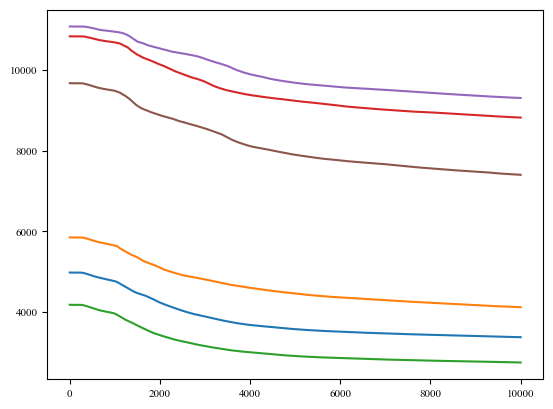

In [21]:
fig, ax = plt.subplots(1,1)
# Mass
ax.plot(a05e00_3d_t, a05e00_3d_Mass, label='a=0.5, eta=0.0')
ax.plot(a05ef5_3d_t, a05ef5_3d_Mass, label='a=0.5, eta=-0.5')
ax.plot(a05ez5_3d_t, a05ez5_3d_Mass, label='a=0.5, eta=0.5')
ax.plot(a09e00_3d_t, a09e00_3d_Mass, label='a=0.9375, eta=0.0')
ax.plot(a09ef1_3d_t, a09ef1_3d_Mass, label='a=0.9375, eta=-0.1')
ax.plot(a09ez5_3d_t, a09ez5_3d_Mass, label='a=0.9375, eta=0.5')

# ax.plot(a05e00_2d_t, a05e00_2d_Mass, label='a=0.5, eta=0.0')
# ax.plot(a05ef5_2d_t, a05ef5_2d_Mass, label='a=0.5, eta=-0.5')
# ax.plot(a05ez5_2d_t, a05ez5_2d_Mass, label='a=0.5, eta=0.5')
# ax.plot(a09e00_2d_t, a09e00_2d_Mass, label='a=0.9375, eta=0.0')
# ax.plot(a09ef1_2d_t, a09ef1_2d_Mass, label='a=0.9375, eta=-0.1')
# ax.plot(a09ez5_2d_t, a09ez5_2d_Mass, label='a=0.9375, eta=0.5')


In [22]:
print(np.array(a05e00_3d_t).shape)
# print(np.array(a05e00_2d_t).shape)

(10001,)


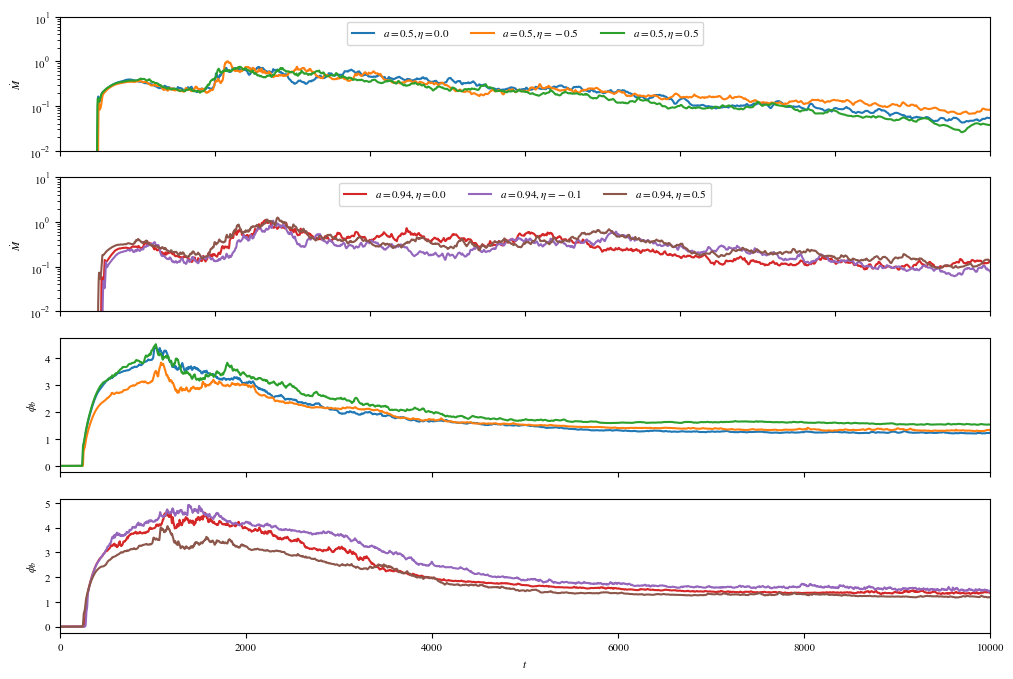

In [23]:
avt = 5000

# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

phi_b_a05e00_3d = [a05e00_3d_t, a05e00_3d_Phi_EH/np.sqrt(np.average(a05e00_3d_Mdot_EH[avt:]))]
phi_b_a05ef5_3d = [a05ef5_3d_t, a05ef5_3d_Phi_EH/np.sqrt(np.average(a05ef5_3d_Mdot_EH[avt:]))]
phi_b_a05ez5_3d = [a05ez5_3d_t, a05ez5_3d_Phi_EH/np.sqrt(np.average(a05ez5_3d_Mdot_EH[avt:]))]
phi_b_a09e00_3d = [a09e00_3d_t, a09e00_3d_Phi_EH/np.sqrt(np.average(a09e00_3d_Mdot_EH[avt:]))]
phi_b_a09ef1_3d = [a09ef1_3d_t, a09ef1_3d_Phi_EH/np.sqrt(np.average(a09ef1_3d_Mdot_EH[avt:]))]
phi_b_a09ez5_3d = [a09ez5_3d_t, a09ez5_3d_Phi_EH/np.sqrt(np.average(a09ez5_3d_Mdot_EH[avt:]))]

# phi_b_a05e00_2d = [a05e00_2d_t, a05e00_2d_Phi_EH/np.sqrt(np.average(a05e00_2d_Mdot_EH[avt:]))]
# phi_b_a05ef5_2d = [a05ef5_2d_t, a05ef5_2d_Phi_EH/np.sqrt(np.average(a05ef5_2d_Mdot_EH[avt:]))]
# phi_b_a05ez5_2d = [a05ez5_2d_t, a05ez5_2d_Phi_EH/np.sqrt(np.average(a05ez5_2d_Mdot_EH[avt:]))]
# phi_b_a09e00_2d = [a09e00_2d_t, a09e00_2d_Phi_EH/np.sqrt(np.average(a09e00_2d_Mdot_EH[avt:]))]
# phi_b_a09ef1_2d = [a09ef1_2d_t, a09ef1_2d_Phi_EH/np.sqrt(np.average(a09ef1_2d_Mdot_EH[avt:]))]
# phi_b_a09ez5_2d = [a09ez5_2d_t, a09ez5_2d_Phi_EH/np.sqrt(np.average(a09ez5_2d_Mdot_EH[avt:]))]


figs0, axs0 = plt.subplots(4, 1, figsize=(12, 8))
axs0[0].plot(a05e00_3d_t[::], a05e00_3d_Mdot_EH[::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
axs0[0].plot(a05ef5_3d_t[::], a05ef5_3d_Mdot_EH[::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
axs0[0].plot(a05ez5_3d_t[::], a05ez5_3d_Mdot_EH[::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
axs0[1].plot(a09e00_3d_t[::], a09e00_3d_Mdot_EH[::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
axs0[1].plot(a09ef1_3d_t[::], a09ef1_3d_Mdot_EH[::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')
axs0[1].plot(a09ez5_3d_t[::], a09ez5_3d_Mdot_EH[::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

# axs0[0,1].plot(a05e00_2d_t[::], a05e00_2d_Mdot_EH[::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[0,1].plot(a05ef5_2d_t[::], a05ef5_2d_Mdot_EH[::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[0,1].plot(a05ez5_2d_t[::], a05ez5_2d_Mdot_EH[::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
# axs0[1,1].plot(a09e00_2d_t[::], a09e00_2d_Mdot_EH[::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[1,1].plot(a09ef1_2d_t[::], a09ef1_2d_Mdot_EH[::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')
# axs0[1,1].plot(a09ez5_2d_t[::], a09ez5_2d_Mdot_EH[::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

y_ticks_mdot_3d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_mdot_2d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_phi_b_3d = [1e0, 1e1]
y_ticks_phi_b_2d = [1e0, 1e1, 1e2]
axs0[0].set_ylabel(r'$\dot{M}$')
axs0[0].set_yscale('log')
axs0[0].set_ylim(1e-2, 1e1)
axs0[0].set_yticks(y_ticks_mdot_3d)
axs0[0].set_xlim(0, 10000)
axs0[0].set_xticklabels([])
axs0[0].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='upper center', ncol=3)

# axs0[0,1].set_ylabel(r'$\dot{M}$')
axs0[0].set_yscale('log')
axs0[0].set_ylim(1e-2, 1e1)
axs0[0].set_yticks(y_ticks_mdot_2d)
axs0[0].set_xlim(0, 6000)
axs0[0].set_xticklabels([])

axs0[1].set_ylabel(r'$\dot{M}$')
axs0[1].set_yscale('log')
axs0[1].set_ylim(1e-2, 1e1)
axs0[1].set_yticks(y_ticks_mdot_3d)
axs0[1].set_xlim(0, 10000)
axs0[1].set_xticklabels([])
axs0[1].legend([r'$a=0.94, \eta=0.0$', r'$a=0.94, \eta=-0.1$', r'$a=0.94, \eta=0.5$'], loc='upper center', ncol=3)

axs0[1].set_yscale('log')
axs0[1].set_ylim(1e-2, 1e1)
axs0[1].set_yticks(y_ticks_mdot_2d)
axs0[1].set_xlim(0, 6000)
axs0[1].set_xticklabels([])


axs0[2].plot(phi_b_a05e00_3d[0][::], phi_b_a05e00_3d[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
axs0[2].plot(phi_b_a05ef5_3d[0][::], phi_b_a05ef5_3d[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
axs0[2].plot(phi_b_a05ez5_3d[0][::], phi_b_a05ez5_3d[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
axs0[3].plot(phi_b_a09e00_3d[0][::], phi_b_a09e00_3d[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
axs0[3].plot(phi_b_a09ef1_3d[0][::], phi_b_a09ef1_3d[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')   
axs0[3].plot(phi_b_a09ez5_3d[0][::], phi_b_a09ez5_3d[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')
# axs0[2,1].plot(phi_b_a05e00_2d[0][::], phi_b_a05e00_2d[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[2,1].plot(phi_b_a05ef5_2d[0][::], phi_b_a05ef5_2d[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[2,1].plot(phi_b_a05ez5_2d[0][::], phi_b_a05ez5_2d[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
# axs0[3,1].plot(phi_b_a09e00_2d[0][::], phi_b_a09e00_2d[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[3,1].plot(phi_b_a09ef1_2d[0][::], phi_b_a09ef1_2d[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')
# axs0[3,1].plot(phi_b_a09ez5_2d[0][::], phi_b_a09ez5_2d[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

axs0[2].set_ylabel(r'$\phi_b$')
# axs0[2].set_yscale('log')
# axs0[2].set_ylim(1e-0, 1e1)
# axs0[2].set_yticks(y_ticks_phi_b_3d)
axs0[2].set_xlim(0, 10000)
axs0[2].set_xticklabels([])
# axs0[2].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='lower right')

axs0[3].set_ylabel(r'$\phi_b$')
# axs0[3,0].set_yscale('log')
# axs0[3,0].set_ylim(1e-0, 1e1)
# axs0[3,0].set_yticks(y_ticks_phi_b_3d)
axs0[3].set_xlabel(r'$t$')
axs0[3].set_xlim(0, 10000)
# axs0[3].legend([r'$a=0.9375, \eta=0.0$', r'$a=0.9375, \eta=-0.1$', r'$a=0.9375, \eta=0.5$'], loc='lower right')

# axs0[2,1].set_yscale('log')
# axs0[2,1].set_ylim(1e-0, 1e2)
# axs0[2,1].set_yticks(y_ticks_phi_b_2d)
# axs0[2].set_xlim(0, 6000)
# axs0[2].set_xticklabels([])

# axs0[3,1].set_yscale('log')
# axs0[3,1].set_ylim(1e-0, 1e2)
# axs0[3,1].set_yticks(y_ticks_phi_b_2d)
# axs0[3].set_xlabel(r'$t$')
# axs0[3].set_xlim(0, 6000)


# plt.savefig('kz_analysis_result_t-mdot_phi_b.png', dpi=300)
plt.show()

In [24]:
# def moving_average(data, window_size):
#     return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# # 对数据进行平滑处理
# window = 50  # 可以调整窗口大小
# a05ef5_2d_Mdot_EH_smoothed_t = a05ef5_2d_Mdot_EH[0][window-1:]  # 需要调整时间数组以匹配平滑后的数据长度
# a05ef5_2d_Mdot_EH_smoothed_data = moving_average(a05ef5_2d_Mdot_EH[1], window)


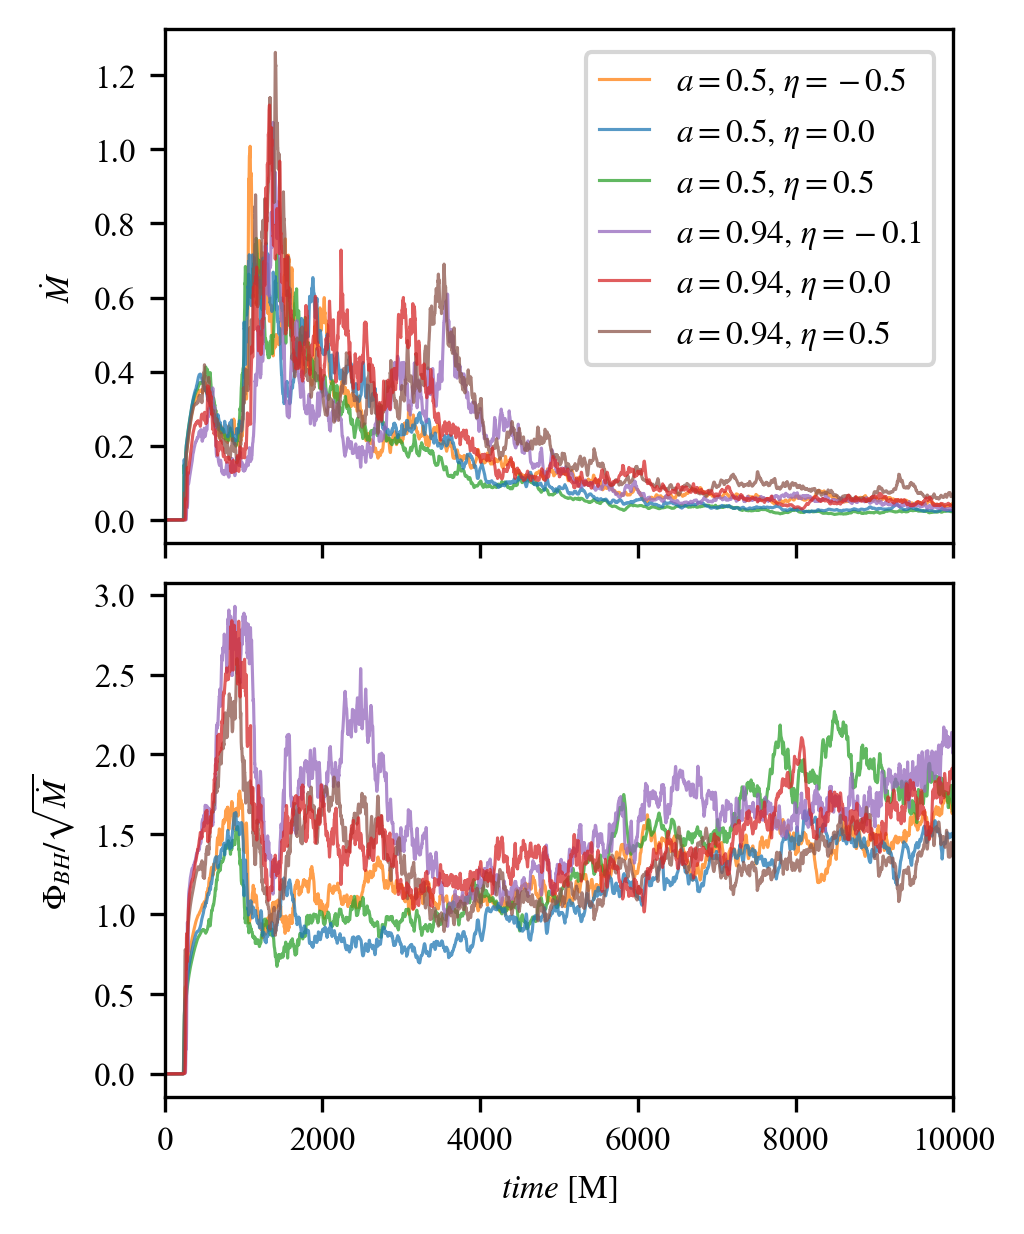

In [44]:
# avt = 5000
# tstart = 0
# tend = 7000
# dt = 20
line_width_3d = 0.75
# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

phi_b_a05e00_3d = [a05e00_3d_t, a05e00_3d_Phi_EH/np.sqrt((a05e00_3d_Mdot_EH[:]))]
phi_b_a05ef5_3d = [a05ef5_3d_t, a05ef5_3d_Phi_EH/np.sqrt((a05ef5_3d_Mdot_EH[:]))]
phi_b_a05ez5_3d = [a05ez5_3d_t, a05ez5_3d_Phi_EH/np.sqrt((a05ez5_3d_Mdot_EH[:]))]
phi_b_a09e00_3d = [a09e00_3d_t, a09e00_3d_Phi_EH/np.sqrt((a09e00_3d_Mdot_EH[:]))]
phi_b_a09ef1_3d = [a09ef1_3d_t, a09ef1_3d_Phi_EH/np.sqrt((a09ef1_3d_Mdot_EH[:]))]
phi_b_a09ez5_3d = [a09ez5_3d_t, a09ez5_3d_Phi_EH/np.sqrt((a09ez5_3d_Mdot_EH[:]))]

# phi_b_a05e00_2d = [a05e00_2d_t, a05e00_2d_Phi_EH/np.sqrt((a05e00_2d_Mdot_EH[:]))]
# phi_b_a05ef5_2d = [a05ef5_2d_t, a05ef5_2d_Phi_EH/np.sqrt((a05ef5_2d_Mdot_EH[:]))]
# phi_b_a05ez5_2d = [a05ez5_2d_t, a05ez5_2d_Phi_EH/np.sqrt((a05ez5_2d_Mdot_EH[:]))]
# phi_b_a09e00_2d = [a09e00_2d_t, a09e00_2d_Phi_EH/np.sqrt((a09e00_2d_Mdot_EH[:]))]
# phi_b_a09ef1_2d = [a09ef1_2d_t, a09ef1_2d_Phi_EH/np.sqrt((a09ef1_2d_Mdot_EH[:]))]
# phi_b_a09ez5_2d = [a09ez5_2d_t, a09ez5_2d_Phi_EH/np.sqrt((a09ez5_2d_Mdot_EH[:]))]


figs0, axs0 = plt.subplots(2, 1, figsize=(3.3, 4), dpi=300, layout='constrained')

axs0[0].plot(a05ef5_3d_t[::], a05ef5_3d_Mdot_EH[::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[0].plot(a05ez5_3d_t[::], a05ez5_3d_Mdot_EH[::], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[0].plot(a05e00_3d_t[::], a05e00_3d_Mdot_EH[::], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=line_width_3d, alpha=0.75)

axs0[0].plot(a09ef1_3d_t[::], a09ef1_3d_Mdot_EH[::], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=line_width_3d, alpha=0.75)
axs0[0].plot(a09ez5_3d_t[::], a09ez5_3d_Mdot_EH[::], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[0].plot(a09e00_3d_t[::], a09e00_3d_Mdot_EH[::], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=line_width_3d, alpha=0.75)


# axs0[0,1].plot(a05ef5_2d_t[::dt], a05ef5_2d_Mdot_EH[::dt], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.0, alpha=0.75)
# axs0[0,1].plot(a05ez5_2d_t[::dt], a05ez5_2d_Mdot_EH[::dt], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.0, alpha=0.75)
# axs0[0,1].plot(a05e00_2d_t[::dt], a05e00_2d_Mdot_EH[::dt], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.0, alpha=0.75)

# axs0[1,1].plot(a09ef1_2d_t[::dt], a09ef1_2d_Mdot_EH[::dt], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.0, alpha=0.75)
# axs0[1,1].plot(a09ez5_2d_t[::dt], a09ez5_2d_Mdot_EH[::dt], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.0, alpha=0.75)
# axs0[1,1].plot(a09e00_2d_t[::dt], a09e00_2d_Mdot_EH[::dt], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.0, alpha=0.75)

y_ticks_mdot_3d = [1e-2, 1e-1, 1e0, 1e1]
# y_ticks_mdot_2d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_phi_b_3d = [1e-1, 1e0, 1e1]
# y_ticks_phi_b_2d = [1e-1, 1e0, 1e1]
axs0[0].set_ylabel(r'$\dot{M}$')
# axs0[0].set_yscale('log')
# axs0[0].set_ylim(1e-2, 1e1)
# axs0[0].set_yticks(y_ticks_mdot_3d)
# axs0[0].set_ylim(0, 1.5)
axs0[0].set_xlim(0, 10000)
axs0[0].set_xticklabels([])
# axs0[0,0].legend(loc='upper right', ncol=1)

# axs0[0,1].set_yscale('log')
# axs0[0,1].set_ylim(1e-2, 1e1)
# axs0[0,1].set_yticks(y_ticks_mdot_2d)
# axs0[0,1].set_ylim(0, 1.5)
# axs0[0,1].set_xlim(tstart, tend)
# axs0[0,1].set_xticklabels([])

# axs0[1].set_ylabel(r'$\dot{M}$')
# axs0[1].set_yscale('log')
# axs0[1].set_ylim(1e-2, 1e1)
# axs0[1].set_yticks(y_ticks_mdot_3d)
# axs0[1].set_ylim(0, 1.5)
# axs0[1].set_xlim(0, 10000)
# axs0[1].set_xticklabels([])
# axs0[1,0].legend(loc='upper right', ncol=1)

# axs0[1,1].set_yscale('log')
# axs0[1,1].set_ylim(1e-3, 1e1)
# axs0[1,1].set_yticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
# axs0[1,1].set_ylim(0, 1.5)
# axs0[1,1].set_xlim(tstart, tend)
# axs0[1,1].set_xticklabels([])


axs0[1].plot(phi_b_a05ef5_3d[0][::], phi_b_a05ef5_3d[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[1].plot(phi_b_a05ez5_3d[0][::], phi_b_a05ez5_3d[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[1].plot(phi_b_a05e00_3d[0][::], phi_b_a05e00_3d[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=line_width_3d, alpha=0.75)

axs0[1].plot(phi_b_a09ef1_3d[0][::], phi_b_a09ef1_3d[1][::], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=line_width_3d, alpha=0.75)   
axs0[1].plot(phi_b_a09ez5_3d[0][::], phi_b_a09ez5_3d[1][::], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=line_width_3d, alpha=0.75)
axs0[1].plot(phi_b_a09e00_3d[0][::], phi_b_a09e00_3d[1][::], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=line_width_3d, alpha=0.75)

# axs0[2,1].plot(phi_b_a05ef5_2d[0][::dt], phi_b_a05ef5_2d[1][::dt], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.0, alpha=0.75)
# axs0[2,1].plot(phi_b_a05ez5_2d[0][::dt], phi_b_a05ez5_2d[1][::dt], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.0, alpha=0.75)
# axs0[2,1].plot(phi_b_a05e00_2d[0][::dt], phi_b_a05e00_2d[1][::dt], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.0, alpha=0.75)

# axs0[3,1].plot(phi_b_a09ef1_2d[0][::dt], phi_b_a09ef1_2d[1][::dt], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.0, alpha=0.75)
# axs0[3,1].plot(phi_b_a09ez5_2d[0][::dt], phi_b_a09ez5_2d[1][::dt], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.0, alpha=0.75)
# axs0[3,1].plot(phi_b_a09e00_2d[0][::dt], phi_b_a09e00_2d[1][::dt], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.0, alpha=0.75)

axs0[1].set_ylabel(r'$\Phi_{BH}/\sqrt{\dot{M}}$')
# axs0[2].set_yscale('log')
# axs0[2].set_ylim(1e-1, 1e1)
# axs0[2].set_yticks(y_ticks_phi_b_3d)
axs0[1].set_xlim(0, 10000)
# axs0[1].set_xticklabels([])

axs0[1].set_ylabel(r'$\Phi_{BH}/\sqrt{\dot{M}}$')
# axs0[3].set_yscale('log')
# axs0[3].set_ylim(1e-1, 1e1)
# axs0[3].set_yticks(y_ticks_phi_b_3d)
axs0[1].set_xlabel(r'$time ~[\mathrm{M}]$')
axs0[1].set_xlim(0, 10000)

# axs0[2,1].set_yscale('log')
# axs0[2,1].set_ylim(1e-1, 1e1)
# axs0[2,1].set_yticks(y_ticks_phi_b_2d)
# axs0[2,1].set_xlim(tstart, tend)
# axs0[2,1].set_xticklabels([])

# axs0[3,1].set_yscale('log')
# axs0[3,1].set_ylim(1e-1, 1e1)
# axs0[3,1].set_yticks(y_ticks_phi_b_2d)
# axs0[3,1].set_xlabel(r'$time ~[M]$')
# axs0[3,1].set_xlim(tstart, tend)

handles_3d = [
    plt.Line2D([], [], color='#ff7f0e', label=r'$a=0.5,\, \eta=-0.5$', linewidth=line_width_3d, alpha=0.75),
    plt.Line2D([], [], color='#1f77b4', label=r'$a=0.5,\, \eta=0.0$', linewidth=line_width_3d, alpha=0.75),
    plt.Line2D([], [], color='#2ca02c', label=r'$a=0.5,\, \eta=0.5$', linewidth=line_width_3d, alpha=0.75),
    plt.Line2D([], [], color='#9467bd', label=r'$a=0.94,\, \eta=-0.1$', linewidth=line_width_3d, alpha=0.75),
    plt.Line2D([], [], color='#d62728', label=r'$a=0.94,\, \eta=0.0$', linewidth=line_width_3d, alpha=0.75),
    plt.Line2D([], [], color='#8c564b', label=r'$a=0.94,\, \eta=0.5$', linewidth=line_width_3d, alpha=0.75)
]

figs0.legend(handles=handles_3d, 
            loc='center', 
            bbox_to_anchor=(0.75, 0.84),  # 调整图例的位置
            ncol=1,                       # 3列
            bbox_transform=figs0.transFigure,
            handlelength=1.5,
            columnspacing=1.0)

# 调整布局以适应顶部的图例
# plt.tight_layout()
# figs0.subplots_adjust(top=0.95)  # 为顶部图例留出空间


# plt.savefig("kz_analysis_result_t-mdot_phi_b.eps", dpi=300, format="eps", bbox_inches="tight")
plt.savefig("kz_analysis_result_t-mdot_phi_b_only_3d.pdf", dpi=300, format="pdf", bbox_inches="tight")
# plt.savefig('kz_analysis_result_t-mdot_phi_b.eps', dpi=300)
plt.show()

In [41]:
ts_3d = 5000
te_3d = 10000
ts_2d = 5000
te_2d = 7000
a05ef5_3d_Mdot_EH[ts_3d:te_3d:]
a05ez5_3d_Mdot_EH[ts_3d:te_3d:]
a05e00_3d_Mdot_EH[ts_3d:te_3d:]
a09ef1_3d_Mdot_EH[ts_3d:te_3d:]
a09ez5_3d_Mdot_EH[ts_3d:te_3d:]
a09e00_3d_Mdot_EH[ts_3d:te_3d:]
a05ef5_2d_Mdot_EH[ts_2d:te_2d:]
a05ez5_2d_Mdot_EH[ts_2d:te_2d:]
a05e00_2d_Mdot_EH[ts_2d:te_2d:]
a09ef1_2d_Mdot_EH[ts_2d:te_2d:]
a09ez5_2d_Mdot_EH[ts_2d:te_2d:]
a09e00_2d_Mdot_EH[ts_2d:te_2d:]

# 计算3D模拟数据的均值和标准差
Mdot_a05ef5_3d_mean = np.mean(a05ef5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a05ef5_3d_std = np.std(a05ef5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a05ez5_3d_mean = np.mean(a05ez5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a05ez5_3d_std = np.std(a05ez5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a05e00_3d_mean = np.mean(a05e00_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a05e00_3d_std = np.std(a05e00_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09ef1_3d_mean = np.mean(a09ef1_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09ef1_3d_std = np.std(a09ef1_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09ez5_3d_mean = np.mean(a09ez5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09ez5_3d_std = np.std(a09ez5_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09e00_3d_mean = np.mean(a09e00_3d_Mdot_EH[ts_3d:te_3d:])
Mdot_a09e00_3d_std = np.std(a09e00_3d_Mdot_EH[ts_3d:te_3d:])

# 计算2D模拟数据的均值和标准差
Mdot_a05ef5_2d_mean = np.mean(a05ef5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a05ef5_2d_std = np.std(a05ef5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a05ez5_2d_mean = np.mean(a05ez5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a05ez5_2d_std = np.std(a05ez5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a05e00_2d_mean = np.mean(a05e00_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a05e00_2d_std = np.std(a05e00_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09ef1_2d_mean = np.mean(a09ef1_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09ef1_2d_std = np.std(a09ef1_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09ez5_2d_mean = np.mean(a09ez5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09ez5_2d_std = np.std(a09ez5_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09e00_2d_mean = np.mean(a09e00_2d_Mdot_EH[ts_2d:te_2d:])
Mdot_a09e00_2d_std = np.std(a09e00_2d_Mdot_EH[ts_2d:te_2d:])

# 打印结果
print("3D模拟数据统计结果:")
print(f"a=0.5, η=-0.5: 均值 = {Mdot_a05ef5_3d_mean:.6f}, 标准差 = {Mdot_a05ef5_3d_std:.6f}")
print(f"a=0.5, η=0.5: 均值 = {Mdot_a05ez5_3d_mean:.6f}, 标准差 = {Mdot_a05ez5_3d_std:.6f}")
print(f"a=0.5, η=0.0: 均值 = {Mdot_a05e00_3d_mean:.6f}, 标准差 = {Mdot_a05e00_3d_std:.6f}")
print(f"a=0.94, η=-0.1: 均值 = {Mdot_a09ef1_3d_mean:.6f}, 标准差 = {Mdot_a09ef1_3d_std:.6f}")
print(f"a=0.94, η=0.5: 均值 = {Mdot_a09ez5_3d_mean:.6f}, 标准差 = {Mdot_a09ez5_3d_std:.6f}")
print(f"a=0.94, η=0.0: 均值 = {Mdot_a09e00_3d_mean:.6f}, 标准差 = {Mdot_a09e00_3d_std:.6f}")

print("\n2D模拟数据统计结果:")
print(f"a=0.5, η=-0.5: 均值 = {Mdot_a05ef5_2d_mean:.6f}, 标准差 = {Mdot_a05ef5_2d_std:.6f}")
print(f"a=0.5, η=0.5: 均值 = {Mdot_a05ez5_2d_mean:.6f}, 标准差 = {Mdot_a05ez5_2d_std:.6f}")
print(f"a=0.5, η=0.0: 均值 = {Mdot_a05e00_2d_mean:.6f}, 标准差 = {Mdot_a05e00_2d_std:.6f}")
print(f"a=0.94, η=-0.1: 均值 = {Mdot_a09ef1_2d_mean:.6f}, 标准差 = {Mdot_a09ef1_2d_std:.6f}")
print(f"a=0.94, η=0.5: 均值 = {Mdot_a09ez5_2d_mean:.6f}, 标准差 = {Mdot_a09ez5_2d_std:.6f}")
print(f"a=0.94, η=0.0: 均值 = {Mdot_a09e00_2d_mean:.6f}, 标准差 = {Mdot_a09e00_2d_std:.6f}")


3D模拟数据统计结果:
a=0.5, η=-0.5: 均值 = 0.066134, 标准差 = 0.019901
a=0.5, η=0.5: 均值 = 0.030828, 标准差 = 0.011674
a=0.5, η=0.0: 均值 = 0.038635, 标准差 = 0.014763
a=0.94, η=-0.1: 均值 = 0.060793, 标准差 = 0.021349
a=0.94, η=0.5: 均值 = 0.093966, 标准差 = 0.027725
a=0.94, η=0.0: 均值 = 0.071383, 标准差 = 0.028354

2D模拟数据统计结果:
a=0.5, η=-0.5: 均值 = 0.039572, 标准差 = 0.041389
a=0.5, η=0.5: 均值 = 0.031530, 标准差 = 0.023876
a=0.5, η=0.0: 均值 = 0.053401, 标准差 = 0.051430
a=0.94, η=-0.1: 均值 = 0.017706, 标准差 = 0.018339
a=0.94, η=0.5: 均值 = 0.041730, 标准差 = 0.044404
a=0.94, η=0.0: 均值 = 0.025524, 标准差 = 0.029734


In [42]:
phi_b_a05ef5_3d[1][ts_3d:te_3d:]
phi_b_a05ez5_3d[1][ts_3d:te_3d:]
phi_b_a05e00_3d[1][ts_3d:te_3d:]
phi_b_a09ef1_3d[1][ts_3d:te_3d:]
phi_b_a09ez5_3d[1][ts_3d:te_3d:]
phi_b_a09e00_3d[1][ts_3d:te_3d:]

phi_b_a05ef5_2d[1][ts_2d:te_2d:]
phi_b_a05ez5_2d[1][ts_2d:te_2d:]
phi_b_a05e00_2d[1][ts_2d:te_2d:]
phi_b_a09ef1_2d[1][ts_2d:te_2d:]
phi_b_a09ez5_2d[1][ts_2d:te_2d:]
phi_b_a09e00_2d[1][ts_2d:te_2d:]

phi_b_a05ef5_3d_mean = np.mean(phi_b_a05ef5_3d[1][ts_3d:te_3d:])
phi_b_a05ez5_3d_mean = np.mean(phi_b_a05ez5_3d[1][ts_3d:te_3d:])
phi_b_a05e00_3d_mean = np.mean(phi_b_a05e00_3d[1][ts_3d:te_3d:])
phi_b_a09ef1_3d_mean = np.mean(phi_b_a09ef1_3d[1][ts_3d:te_3d:])
phi_b_a09ez5_3d_mean = np.mean(phi_b_a09ez5_3d[1][ts_3d:te_3d:])
phi_b_a09e00_3d_mean = np.mean(phi_b_a09e00_3d[1][ts_3d:te_3d:])
phi_b_a05ef5_2d_mean = np.mean(phi_b_a05ef5_2d[1][ts_2d:te_2d:])
phi_b_a05ez5_2d_mean = np.mean(phi_b_a05ez5_2d[1][ts_2d:te_2d:])
phi_b_a05e00_2d_mean = np.mean(phi_b_a05e00_2d[1][ts_2d:te_2d:])
phi_b_a09ef1_2d_mean = np.mean(phi_b_a09ef1_2d[1][ts_2d:te_2d:])
phi_b_a09ez5_2d_mean = np.mean(phi_b_a09ez5_2d[1][ts_2d:te_2d:])
phi_b_a09e00_2d_mean = np.mean(phi_b_a09e00_2d[1][ts_2d:te_2d:])

phi_b_a05ef5_3d_std = np.std(phi_b_a05ef5_3d[1][ts_3d:te_3d:])
phi_b_a05ez5_3d_std = np.std(phi_b_a05ez5_3d[1][ts_3d:te_3d:])
phi_b_a05e00_3d_std = np.std(phi_b_a05e00_3d[1][ts_3d:te_3d:])
phi_b_a09ef1_3d_std = np.std(phi_b_a09ef1_3d[1][ts_3d:te_3d:])
phi_b_a09ez5_3d_std = np.std(phi_b_a09ez5_3d[1][ts_3d:te_3d:])
phi_b_a09e00_3d_std = np.std(phi_b_a09e00_3d[1][ts_3d:te_3d:])
phi_b_a05ef5_2d_std = np.std(phi_b_a05ef5_2d[1][ts_2d:te_2d:])
phi_b_a05ez5_2d_std = np.std(phi_b_a05ez5_2d[1][ts_2d:te_2d:])
phi_b_a05e00_2d_std = np.std(phi_b_a05e00_2d[1][ts_2d:te_2d:])
phi_b_a09ef1_2d_std = np.std(phi_b_a09ef1_2d[1][ts_2d:te_2d:])
phi_b_a09ez5_2d_std = np.std(phi_b_a09ez5_2d[1][ts_2d:te_2d:])
phi_b_a09e00_2d_std = np.std(phi_b_a09e00_2d[1][ts_2d:te_2d:])

# 打印结果
print("3D模拟数据统计结果:")
print(f"a=0.5, η=-0.5: 均值 = {phi_b_a05ef5_3d_mean:.6f}, 标准差 = {phi_b_a05ef5_3d_std:.6f}")
print(f"a=0.5, η=0.5: 均值 = {phi_b_a05ez5_3d_mean:.6f}, 标准差 = {phi_b_a05ez5_3d_std:.6f}")
print(f"a=0.5, η=0.0: 均值 = {phi_b_a05e00_3d_mean:.6f}, 标准差 = {phi_b_a05e00_3d_std:.6f}")
print(f"a=0.94, η=-0.1: 均值 = {phi_b_a09ef1_3d_mean:.6f}, 标准差 = {phi_b_a09ef1_3d_std:.6f}")
print(f"a=0.94, η=0.5: 均值 = {phi_b_a09ez5_3d_mean:.6f}, 标准差 = {phi_b_a09ez5_3d_std:.6f}")
print(f"a=0.94, η=0.0: 均值 = {phi_b_a09e00_3d_mean:.6f}, 标准差 = {phi_b_a09e00_3d_std:.6f}")

print("\n2D模拟数据统计结果:")
print(f"a=0.5, η=-0.5: 均值 = {phi_b_a05ef5_2d_mean:.6f}, 标准差 = {phi_b_a05ef5_2d_std:.6f}")
print(f"a=0.5, η=0.5: 均值 = {phi_b_a05ez5_2d_mean:.6f}, 标准差 = {phi_b_a05ez5_2d_std:.6f}")
print(f"a=0.5, η=0.0: 均值 = {phi_b_a05e00_2d_mean:.6f}, 标准差 = {phi_b_a05e00_2d_std:.6f}")
print(f"a=0.94, η=-0.1: 均值 = {phi_b_a09ef1_2d_mean:.6f}, 标准差 = {phi_b_a09ef1_2d_std:.6f}")
print(f"a=0.94, η=0.5: 均值 = {phi_b_a09ez5_2d_mean:.6f}, 标准差 = {phi_b_a09ez5_2d_std:.6f}")
print(f"a=0.94, η=0.0: 均值 = {phi_b_a09e00_2d_mean:.6f}, 标准差 = {phi_b_a09e00_2d_std:.6f}")

3D模拟数据统计结果:
a=0.5, η=-0.5: 均值 = 1.407054, 标准差 = 0.138973
a=0.5, η=0.5: 均值 = 1.674888, 标准差 = 0.254923
a=0.5, η=0.0: 均值 = 1.324109, 标准差 = 0.156437
a=0.94, η=-0.1: 均值 = 1.675301, 标准差 = 0.171408
a=0.94, η=0.5: 均值 = 1.325045, 标准差 = 0.135479
a=0.94, η=0.0: 均值 = 1.509216, 标准差 = 0.211763

2D模拟数据统计结果:
a=0.5, η=-0.5: 均值 = 2.751545, 标准差 = 0.692823
a=0.5, η=0.5: 均值 = 3.131285, 标准差 = 0.664725
a=0.5, η=0.0: 均值 = 2.528628, 标准差 = 0.617810
a=0.94, η=-0.1: 均值 = 4.495990, 标准差 = 1.478500
a=0.94, η=0.5: 均值 = 3.384347, 标准差 = 1.138193
a=0.94, η=0.0: 均值 = 4.590402, 标准差 = 1.376466


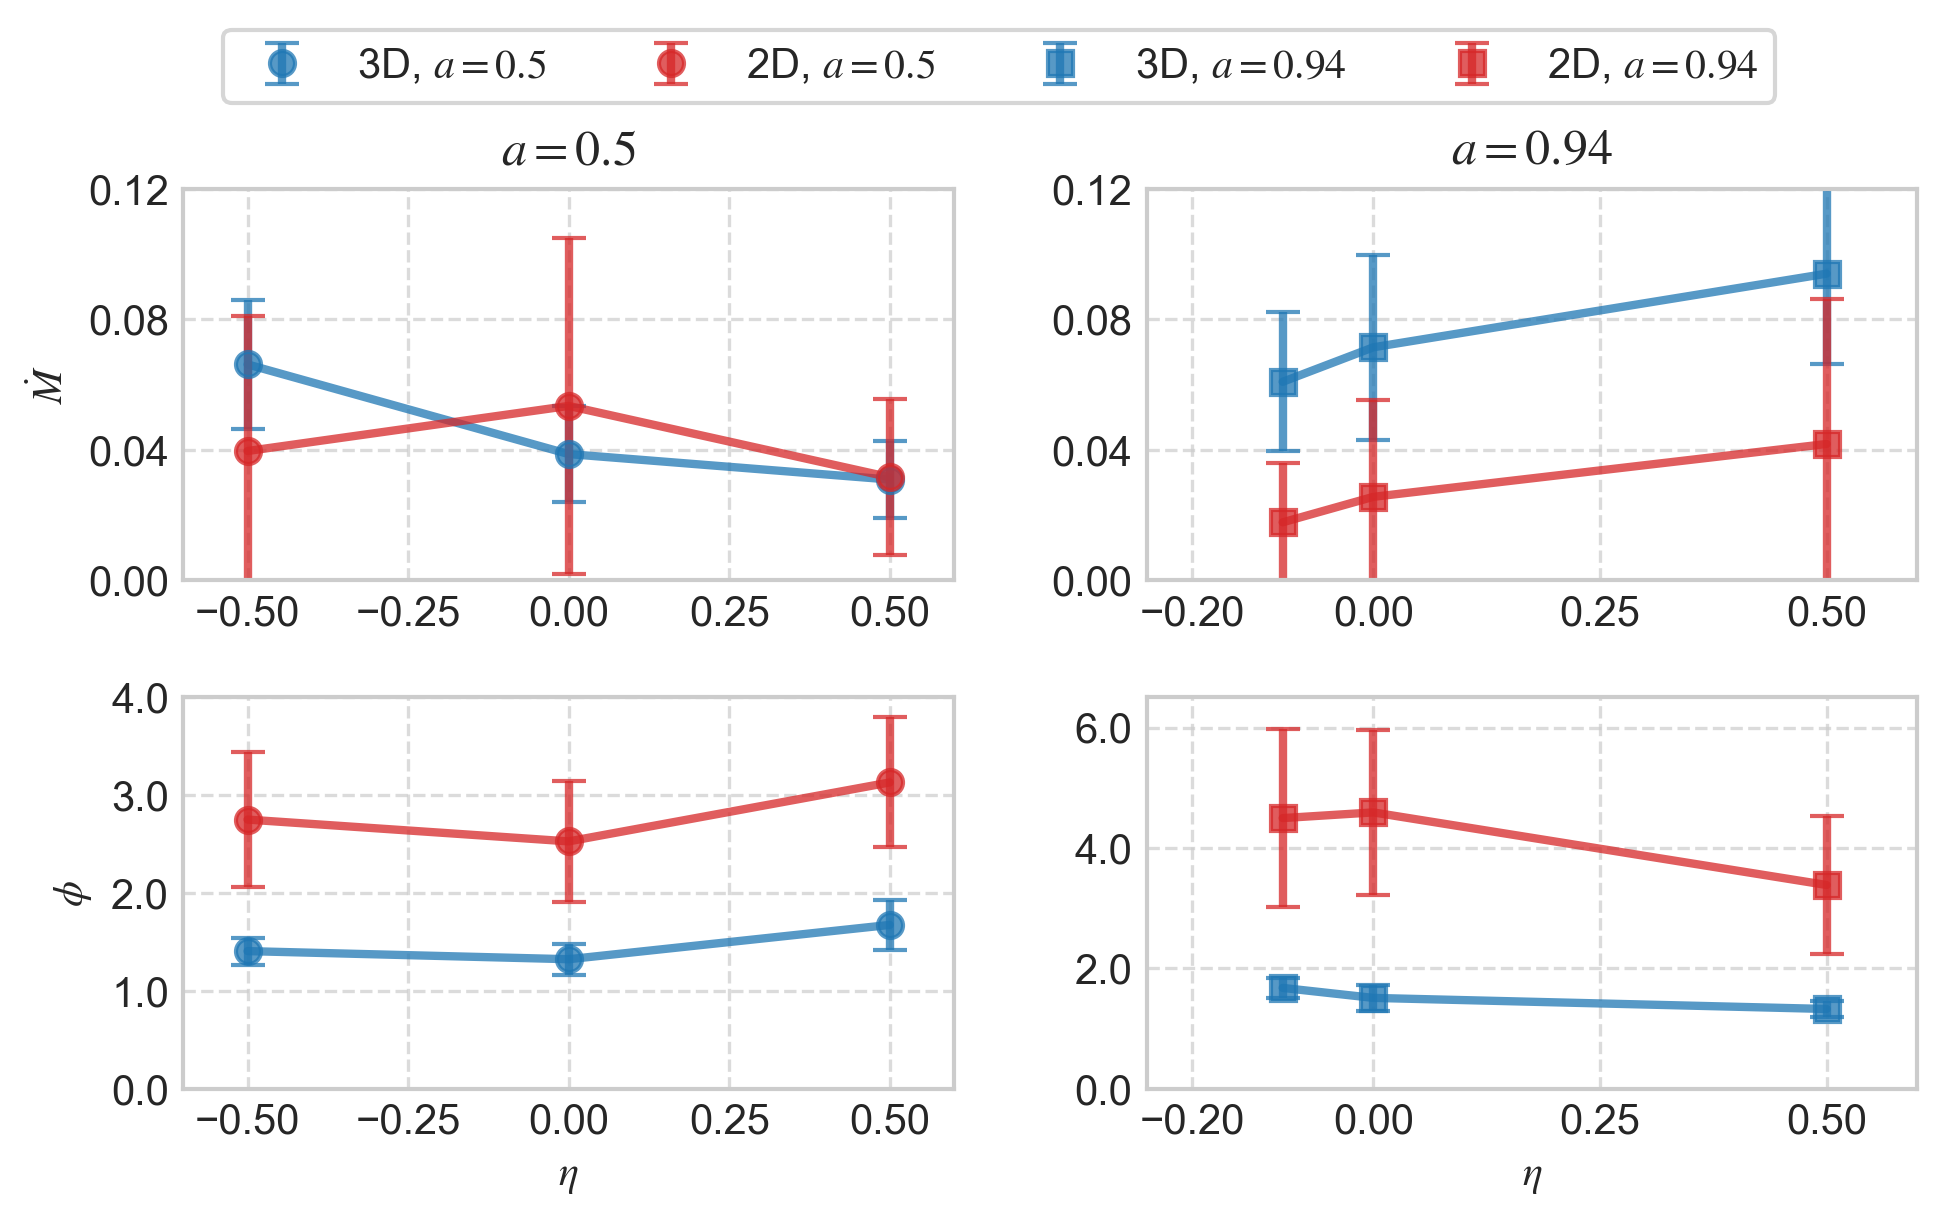

In [53]:
# 创建数据点
eta_values = [-0.5, 0.0, 0.5, -0.1, 0.0, 0.5]
a_values = [0.5, 0.5, 0.5, 0.94, 0.94, 0.94]
labels = [ r'a=0.5, $\eta=-0.5$', r'a=0.5, $\eta=0.0$', r'a=0.5, $\eta=0.5$', r'a=0.94, $\eta=-0.1$', r'a=0.94, $\eta=0.0$', r'a=0.94, $\eta=0.5$']

# 提取吸积率数据
Mdot_3d_means = [Mdot_a05ef5_3d_mean, Mdot_a05e00_3d_mean, Mdot_a05ez5_3d_mean, 
                Mdot_a09ef1_3d_mean, Mdot_a09e00_3d_mean, Mdot_a09ez5_3d_mean]
Mdot_3d_stds = [Mdot_a05ef5_3d_std, Mdot_a05e00_3d_std, Mdot_a05ez5_3d_std, 
               Mdot_a09ef1_3d_std, Mdot_a09e00_3d_std, Mdot_a09ez5_3d_std]

Mdot_2d_means = [Mdot_a05ef5_2d_mean, Mdot_a05e00_2d_mean, Mdot_a05ez5_2d_mean, 
                Mdot_a09ef1_2d_mean, Mdot_a09e00_2d_mean, Mdot_a09ez5_2d_mean]
Mdot_2d_stds = [Mdot_a05ef5_2d_std, Mdot_a05e00_2d_std, Mdot_a05ez5_2d_std, 
               Mdot_a09ef1_2d_std, Mdot_a09e00_2d_std, Mdot_a09ez5_2d_std]

# 提取磁通量数据
phi_3d_means = [phi_b_a05ef5_3d_mean, phi_b_a05e00_3d_mean, phi_b_a05ez5_3d_mean, 
                phi_b_a09ef1_3d_mean, phi_b_a09e00_3d_mean, phi_b_a09ez5_3d_mean]
phi_3d_stds = [phi_b_a05ef5_3d_std, phi_b_a05e00_3d_std, phi_b_a05ez5_3d_std, 
               phi_b_a09ef1_3d_std, phi_b_a09e00_3d_std, phi_b_a09ez5_3d_std]

phi_2d_means = [phi_b_a05ef5_2d_mean, phi_b_a05e00_2d_mean, phi_b_a05ez5_2d_mean, 
                phi_b_a09ef1_2d_mean, phi_b_a09e00_2d_mean, phi_b_a09ez5_2d_mean]
phi_2d_stds = [phi_b_a05ef5_2d_std, phi_b_a05e00_2d_std, phi_b_a05ez5_2d_std, 
               phi_b_a09ef1_2d_std, phi_b_a09e00_2d_std, phi_b_a09ez5_2d_std]

# 创建图形并设置样式
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(6.8, 4), dpi=300)

# 分离a=0.5和a=0.94的数据点
a05_indices = [i for i, a in enumerate(a_values) if a == 0.5]
a09_indices = [i for i, a in enumerate(a_values) if a == 0.94]

# 设置颜色和标记
colors_3d = '#1f77b4'  # 蓝色
colors_2d = '#d62728'  # 红色
marker_a05 = 'o'
marker_a09 = 's'
marker_size = 6
cap_size = 4
line_width = 2
alpha = 0.75

# 绘制吸积率图 (a=0.5)
axs[0,0].errorbar([eta_values[i] for i in a05_indices], [Mdot_3d_means[i] for i in a05_indices], 
                yerr=[Mdot_3d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'3D, $a=0.5$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0,0].plot([eta_values[i] for i in a05_indices], [Mdot_3d_means[i] for i in a05_indices], 
                '-', color=colors_3d, linewidth=line_width, alpha=alpha)

axs[0,0].errorbar([eta_values[i] for i in a05_indices], [Mdot_2d_means[i] for i in a05_indices], 
                yerr=[Mdot_2d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'2D, $a=0.5$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0,0].plot([eta_values[i] for i in a05_indices], [Mdot_2d_means[i] for i in a05_indices], 
                '-', color=colors_2d, linewidth=line_width, alpha=alpha)

# 绘制吸积率图 (a=0.94)
axs[0,1].errorbar([eta_values[i] for i in a09_indices], [Mdot_3d_means[i] for i in a09_indices], 
                yerr=[Mdot_3d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'3D, $a=0.94$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0,1].plot([eta_values[i] for i in a09_indices], [Mdot_3d_means[i] for i in a09_indices], 
                '-', color=colors_3d, linewidth=line_width, alpha=alpha)

axs[0,1].errorbar([eta_values[i] for i in a09_indices], [Mdot_2d_means[i] for i in a09_indices], 
                yerr=[Mdot_2d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'2D, $a=0.94$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0,1].plot([eta_values[i] for i in a09_indices], [Mdot_2d_means[i] for i in a09_indices], 
                '-', color=colors_2d, linewidth=line_width, alpha=alpha)

# 绘制phi值图 (a=0.5)
axs[1,0].errorbar([eta_values[i] for i in a05_indices], [phi_3d_means[i] for i in a05_indices], 
                yerr=[phi_3d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'3D, $a=0.5$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1,0].plot([eta_values[i] for i in a05_indices], [phi_3d_means[i] for i in a05_indices], 
                '-', color=colors_3d, linewidth=line_width, alpha=alpha)

axs[1,0].errorbar([eta_values[i] for i in a05_indices], [phi_2d_means[i] for i in a05_indices], 
                yerr=[phi_2d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'2D, $a=0.5$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1,0].plot([eta_values[i] for i in a05_indices], [phi_2d_means[i] for i in a05_indices], 
                '-', color=colors_2d, linewidth=line_width, alpha=alpha)

# 绘制phi值图 (a=0.94)
axs[1,1].errorbar([eta_values[i] for i in a09_indices], [phi_3d_means[i] for i in a09_indices], 
                yerr=[phi_3d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'3D, $a=0.94$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1,1].plot([eta_values[i] for i in a09_indices], [phi_3d_means[i] for i in a09_indices], 
                '-', color=colors_3d, linewidth=line_width, alpha=alpha)

axs[1,1].errorbar([eta_values[i] for i in a09_indices], [phi_2d_means[i] for i in a09_indices], 
                yerr=[phi_2d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'2D, $a=0.94$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1,1].plot([eta_values[i] for i in a09_indices], [phi_2d_means[i] for i in a09_indices], 
                '-', color=colors_2d, linewidth=line_width, alpha=alpha)

axs[0,0].set_xlim(-0.6, 0.6)
axs[0,1].set_xlim(-0.25, 0.6)
axs[1,0].set_xlim(-0.6, 0.6)
axs[1,1].set_xlim(-0.25, 0.6)

axs[0,0].set_xticks([-0.5, -0.25, 0.0, 0.25, 0.5])
axs[0,1].set_xticks([-0.2,  0.0, 0.25, 0.5])
axs[1,0].set_xticks([-0.5, -0.25, 0.0, 0.25, 0.5])
axs[1,1].set_xticks([-0.2,  0.0, 0.25, 0.5])

axs[0,0].set_ylim(0, 0.12)
axs[0,1].set_ylim(0, 0.12)
axs[1,0].set_ylim(0, 4)
axs[1,1].set_ylim(0, 6.5)

axs[0,0].set_yticks([0, 0.04, 0.08, 0.12])
axs[0,1].set_yticks([0, 0.04, 0.08, 0.12])
axs[1,0].set_yticks([0.0, 1.0, 2.0, 3.0, 4.0], ["0.0", "1.0", "2.0", "3.0", "4.0"])
axs[1,1].set_yticks([0.0, 2.0, 4.0, 6.0], ["0.0", "2.0", "4.0", "6.0"])

# 设置标签和标题
for i in range(2):
    for j in range(2):
        axs[i,j].tick_params(axis='both', which='major')
        axs[i,j].grid(True, linestyle='--', alpha=0.7)
        # axs[i,j].legend( framealpha=0.7)

axs[1,0].set_xlabel(r'$\eta$')
axs[1,1].set_xlabel(r'$\eta$')
# 设置y轴标签
# for i in range(2):
axs[0,0].set_ylabel(r'$\dot{M}$')
axs[1,0].set_ylabel(r'$\phi$')

# 设置子图标题
axs[0,0].set_title(r'$a = 0.5$')
axs[0,1].set_title(r'$a = 0.94$')

# 添加总的图例到图像最上方
handles, labels = [], []
# 获取第一个子图的图例元素（a=0.5）
h1, l1 = axs[0,0].get_legend_handles_labels()
handles.extend(h1[:2])  # 只取3D和2D的图例
labels.extend(l1[:2])
# 获取第二个子图的图例元素（a=0.94）
h2, l2 = axs[0,1].get_legend_handles_labels()
handles.extend(h2[:2])  # 添加a=0.94的3D和2D图例
labels.extend(l2[:2])

# 在图像顶部添加图例
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.0), 
           ncol=4, frameon=True, framealpha=0.8, fontsize=10)

# 调整子图之间的间距，为顶部图例留出空间
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.85, wspace=0.25, hspace=0.3)

plt.savefig('kz_means-std.png', dpi=300)
# 显示图形
plt.show()


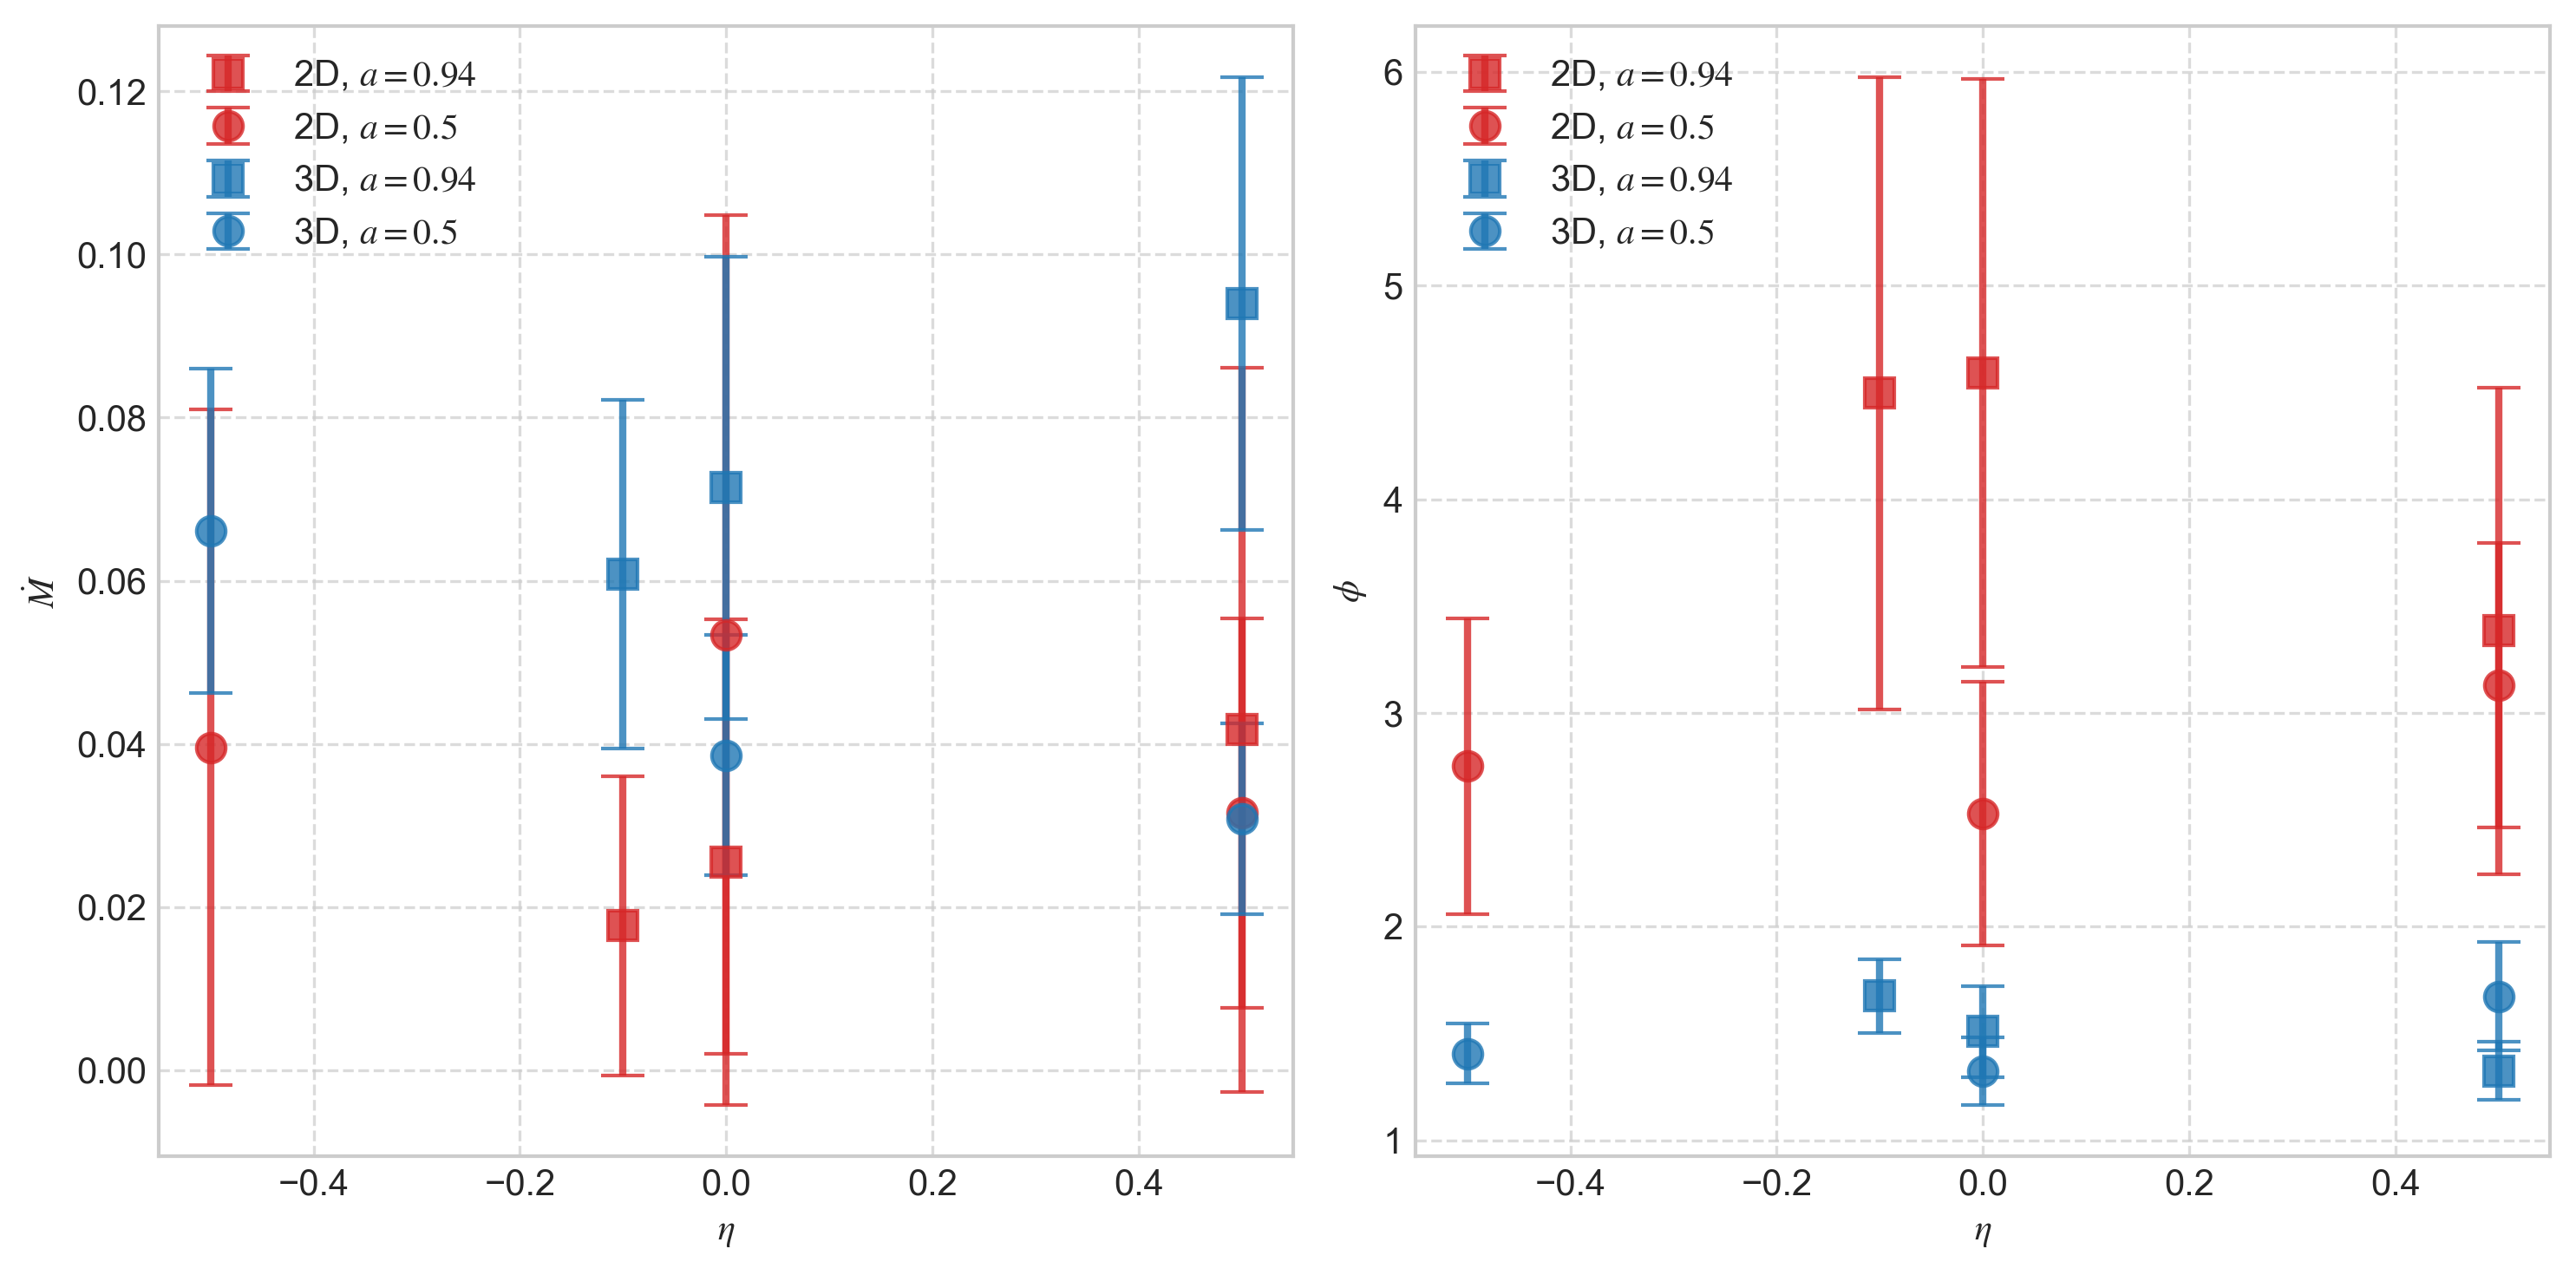

In [44]:
# 创建数据点
eta_values = [-0.5, 0.0, 0.5, -0.1, 0.5, 0.0]
a_values = [0.5, 0.5, 0.5, 0.94, 0.94, 0.94]
labels = [ r'a=0.5, $\eta=-0.5$', r'a=0.5, $\eta=0.0$', r'a=0.5, $\eta=0.5$', r'a=0.94, $\eta=-0.1$', r'a=0.94, $\eta=0.5$', r'a=0.94, $\eta=0.0$']

# 提取吸积率数据
Mdot_3d_means = [Mdot_a05ef5_3d_mean, Mdot_a05e00_3d_mean, Mdot_a05ez5_3d_mean, 
                Mdot_a09ef1_3d_mean, Mdot_a09ez5_3d_mean, Mdot_a09e00_3d_mean]
Mdot_3d_stds = [Mdot_a05ef5_3d_std, Mdot_a05e00_3d_std, Mdot_a05ez5_3d_std, 
               Mdot_a09ef1_3d_std, Mdot_a09ez5_3d_std, Mdot_a09e00_3d_std]

Mdot_2d_means = [Mdot_a05ef5_2d_mean, Mdot_a05e00_2d_mean, Mdot_a05ez5_2d_mean, 
                Mdot_a09ef1_2d_mean, Mdot_a09ez5_2d_mean, Mdot_a09e00_2d_mean]
Mdot_2d_stds = [Mdot_a05ef5_2d_std, Mdot_a05e00_2d_std, Mdot_a05ez5_2d_std, 
               Mdot_a09ef1_2d_std, Mdot_a09ez5_2d_std, Mdot_a09e00_2d_std]

# 提取磁通量数据
phi_3d_means = [phi_b_a05ef5_3d_mean, phi_b_a05e00_3d_mean, phi_b_a05ez5_3d_mean, 
                phi_b_a09ef1_3d_mean, phi_b_a09ez5_3d_mean, phi_b_a09e00_3d_mean]
phi_3d_stds = [phi_b_a05ef5_3d_std, phi_b_a05e00_3d_std, phi_b_a05ez5_3d_std, 
               phi_b_a09ef1_3d_std, phi_b_a09ez5_3d_std, phi_b_a09e00_3d_std]

phi_2d_means = [phi_b_a05ef5_2d_mean, phi_b_a05e00_2d_mean, phi_b_a05ez5_2d_mean, 
                phi_b_a09ef1_2d_mean, phi_b_a09ez5_2d_mean, phi_b_a09e00_2d_mean]
phi_2d_stds = [phi_b_a05ef5_2d_std, phi_b_a05e00_2d_std, phi_b_a05ez5_2d_std, 
               phi_b_a09ef1_2d_std, phi_b_a09ez5_2d_std, phi_b_a09e00_2d_std]

# 创建图形并设置样式
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# 分离a=0.5和a=0.94的数据点
a05_indices = [i for i, a in enumerate(a_values) if a == 0.5]
a09_indices = [i for i, a in enumerate(a_values) if a == 0.94]

# 设置颜色和标记
colors_3d = '#1f77b4'  # 蓝色
colors_2d = '#d62728'  # 红色
marker_a05 = 'o'
marker_a09 = 's'
marker_size = 8
cap_size = 6
line_width = 2
alpha = 0.8

# 绘制吸积率图（左图）
axs[0].errorbar([eta_values[i] for i in a09_indices], [Mdot_2d_means[i] for i in a09_indices], 
                yerr=[Mdot_2d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'2D, $a=0.94$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0].errorbar([eta_values[i] for i in a05_indices], [Mdot_2d_means[i] for i in a05_indices], 
                yerr=[Mdot_2d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'2D, $a=0.5$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0].errorbar([eta_values[i] for i in a09_indices], [Mdot_3d_means[i] for i in a09_indices], 
                yerr=[Mdot_3d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'3D, $a=0.94$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[0].errorbar([eta_values[i] for i in a05_indices], [Mdot_3d_means[i] for i in a05_indices], 
                yerr=[Mdot_3d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'3D, $a=0.5$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)


# 绘制phi值图（右图）
axs[1].errorbar([eta_values[i] for i in a09_indices], [phi_2d_means[i] for i in a09_indices], 
                yerr=[phi_2d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'2D, $a=0.94$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1].errorbar([eta_values[i] for i in a05_indices], [phi_2d_means[i] for i in a05_indices], 
                yerr=[phi_2d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'2D, $a=0.5$', capsize=cap_size, color=colors_2d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1].errorbar([eta_values[i] for i in a09_indices], [phi_3d_means[i] for i in a09_indices], 
                yerr=[phi_3d_stds[i] for i in a09_indices], fmt=marker_a09, 
                label=r'3D, $a=0.94$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)
axs[1].errorbar([eta_values[i] for i in a05_indices], [phi_3d_means[i] for i in a05_indices], 
                yerr=[phi_3d_stds[i] for i in a05_indices], fmt=marker_a05, 
                label=r'3D, $a=0.5$', capsize=cap_size, color=colors_3d, 
                markersize=marker_size, linewidth=line_width, alpha=alpha)

# 设置标签和标题
for i in range(2):
    axs[i].set_xlabel(r'$\eta$')
    axs[i].tick_params(axis='both', which='major')
    axs[i].grid(True, linestyle='--', alpha=0.7)
    axs[i].legend(framealpha=0.7)

# 设置y轴标签
axs[0].set_ylabel(r'$\dot{M}$')
axs[1].set_ylabel(r'$\phi$')

# 设置子图标题
# axs[0].set_title(r'吸积率随$\eta$的变化')
# axs[1].set_title(r'磁通量随$\eta$的变化')

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()

In [45]:
# avt = 5000

# mdot_a05e00 = [t0, Mdot_EH0]
# mdot_a05ef5 = [t2, Mdot_EH2]
# mdot_a05ez5 = [t3, Mdot_EH3]
# mdot_a09e00 = [t1, Mdot_EH1]
# mdot_a09ef1 = [t4, Mdot_EH4]
# mdot_a09ez5 = [t5, Mdot_EH5]

# # phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# # phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# # phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# # phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# # phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# # phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot_EH0[:])]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot_EH2[:])]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot_EH3[:])]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot_EH1[:])]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot_EH4[:])]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot_EH5[:])]

# figs0, axs0 = plt.subplots(4, 1, figsize=(6.4, 8), sharex=True)
# axs0[0].plot(mdot_a05e00[0][::], mdot_a05e00[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[0].plot(mdot_a05ef5[0][::], mdot_a05ef5[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[0].plot(mdot_a05ez5[0][::], mdot_a05ez5[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')

# axs0[1].plot(mdot_a09e00[0][::], mdot_a09e00[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[1].plot(mdot_a09ef1[0][::], mdot_a09ef1[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')
# axs0[1].plot(mdot_a09ez5[0][::], mdot_a09ez5[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

# axs0[0].set_ylabel(r'$\dot{M}$')
# # axs0[0].set_yscale('log')
# # axs0[0].set_ylim(1e-2, 1e1)
# # y_ticks = [1e-2, 1e-1, 1e0, 1e1]
# # axs0[0].set_yticks(y_ticks)
# axs0[0].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='upper center', ncol=3)

# axs0[1].set_ylabel(r'$\dot{M}$')
# # axs0[1].set_yscale('log')
# # axs0[1].set_ylim(1e-2, 1e1)
# # axs0[1].set_yticks(y_ticks)
# axs0[1].legend([r'$a=0.94, \eta=0.0$', r'$a=0.94, \eta=-0.1$', r'$a=0.94, \eta=0.5$'], loc='upper center', ncol=3)

# axs0[2].plot(phi_b_a05e00[0][::], phi_b_a05e00[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[2].plot(phi_b_a05ef5[0][::], phi_b_a05ef5[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[2].plot(phi_b_a05ez5[0][::], phi_b_a05ez5[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
# axs0[3].plot(phi_b_a09e00[0][::], phi_b_a09e00[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[3].plot(phi_b_a09ef1[0][::], phi_b_a09ef1[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')   
# axs0[3].plot(phi_b_a09ez5[0][::], phi_b_a09ez5[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

# axs0[2].set_ylabel(r'$\phi_b$')
# # axs0[2].set_yscale('log')
# # axs0[2].set_ylim(1e-1, 1e1)
# # y_ticks = [ 1e-1,  1e0,  1e1]
# # axs0[2].set_yticks(y_ticks)
# # axs0[2].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='lower right')

# axs0[3].set_ylabel(r'$\phi_b$')
# # axs0[3].set_yscale('log')
# # axs0[3].set_ylim(1e-1, 1e1)
# # axs0[3].set_yticks(y_ticks)
# axs0[3].set_xlabel(r'$t$')
# # axs0[3].legend([r'$a=0.9375, \eta=0.0$', r'$a=0.9375, \eta=-0.1$', r'$a=0.9375, \eta=0.5$'], loc='lower right')


# plt.savefig('kz_analysis_result_t-mdot_phi_b.png', dpi=300)
# plt.show()

In [46]:
# # 均值和标准差分析
# a05e00_3d_Mdot_EH_mean = np.mean(a05e00_3d_Mdot_EH[5000:])
# a05e00_3d_Mdot_EH_std = np.std(a05e00_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=0.0 的均值和标准差分别为: {a05e00_3d_Mdot_EH_mean}, {a05e00_3d_Mdot_EH_std}")

# a05ef5_3d_Mdot_EH_mean = np.mean(a05ef5_3d_Mdot_EH[5000:])
# a05ef5_3d_Mdot_EH_std = np.std(a05ef5_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=-0.5 的均值和标准差分别为: {a05ef5_3d_Mdot_EH_mean}, {a05ef5_3d_Mdot_EH_std}")

# a05ez5_3d_Mdot_EH_mean = np.mean(a05ez5_3d_Mdot_EH[5000:])
# a05ez5_3d_Mdot_EH_std = np.std(a05ez5_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=0.5 的均值和标准差分别为: {a05ez5_3d_Mdot_EH_mean}, {a05ez5_3d_Mdot_EH_std}")

# # 分别进行归一化并进行傅立叶分析
# # 归一化数据
# def normalize_data(data):
#     return (data - np.mean(data)) / np.std(data)

# # 选择稳态阶段的数据（t>5000）进行分析
# start_idx = 5000
# a05e00_norm = normalize_data(a05e00_3d_Mdot_EH[start_idx:])
# a05ef5_norm = normalize_data(a05ef5_3d_Mdot_EH[start_idx:])
# a05ez5_norm = normalize_data(a05ez5_3d_Mdot_EH[start_idx:])

# # 计算时间序列的采样率和长度
# dt = 0.1  # 假设时间间隔是均匀的
# fs = 1/dt  # 采样率
# N = len(a05e00_norm)  # 数据点数

# # 进行傅立叶变换
# a05e00_fft = np.fft.rfft(a05e00_norm)
# a05ef5_fft = np.fft.rfft(a05ef5_norm)
# a05ez5_fft = np.fft.rfft(a05ez5_norm)

# # 计算频率轴
# freq = np.fft.rfftfreq(N, d=dt)

# # 计算功率谱密度
# a05e00_psd = np.abs(a05e00_fft)**2
# a05ef5_psd = np.abs(a05ef5_fft)**2
# a05ez5_psd = np.abs(a05ez5_fft)**2

# # 绘制功率谱密度图
# plt.figure(figsize=(12, 8))
# plt.loglog(freq, a05e00_psd, label=r'$a=0.5, \eta=0.0$')
# plt.loglog(freq, a05ef5_psd, label=r'$a=0.5, \eta=-0.5$')
# plt.loglog(freq, a05ez5_psd, label=r'$a=0.5, \eta=0.5$')
# plt.xlabel('frequency (Hz)')
# plt.ylabel('power spectral density')
# plt.title('power spectral density of mass accretion rate')
# plt.legend()
# plt.grid(True, which="both", ls="--")
# plt.tight_layout()
# plt.savefig('kz_analysis_psd.png', dpi=300)
# plt.show()

# # 寻找主要频率
# def find_peak_frequencies(freq, psd, n_peaks=3):
#     peak_indices = np.argsort(psd)[-n_peaks:]
#     peak_freqs = freq[peak_indices]
#     peak_powers = psd[peak_indices]
#     return peak_freqs, peak_powers

# print("main frequency analysis:")
# for name, f, p in zip(
#     ["a=0.5, η=0.0", "a=0.5, η=-0.5", "a=0.5, η=0.5"],
#     [a05e00_psd, a05ef5_psd, a05ez5_psd],
#     [freq, freq, freq]
# ):
#     peak_freqs, peak_powers = find_peak_frequencies(p, f)
#     print(f"{name} 的主要频率: {peak_freqs}")
#     print(f"对应的功率: {peak_powers}")
#     print("周期: ", 1/peak_freqs)
#     print("-" * 40)




In [47]:
# # 计算KL散度来比较不同模型的功率谱密度分布差异
# from scipy import stats
# import numpy as np

# # 将功率谱密度归一化为概率分布
# def normalize_to_pdf(psd):
#     return psd / np.sum(psd)

# # 计算KL散度
# def kl_divergence(p, q):
#     # 避免零值
#     p = np.maximum(p, 1e-10)
#     q = np.maximum(q, 1e-10)
#     return np.sum(p * np.log(p / q))

# # 归一化PSD
# a05e00_pdf = normalize_to_pdf(a05e00_psd)
# a05ef5_pdf = normalize_to_pdf(a05ef5_psd)
# a05ez5_pdf = normalize_to_pdf(a05ez5_psd)

# # 计算KL散度
# kl_00_f5 = kl_divergence(a05e00_pdf, a05ef5_pdf)
# kl_00_z5 = kl_divergence(a05e00_pdf, a05ez5_pdf)
# kl_f5_z5 = kl_divergence(a05ef5_pdf, a05ez5_pdf)

# print("KL散度分析结果:")
# print(f"η=0.0 与 η=-0.5 之间的KL散度: {kl_00_f5:.4f}")
# print(f"η=0.0 与 η=0.5 之间的KL散度: {kl_00_z5:.4f}")
# print(f"η=-0.5 与 η=0.5 之间的KL散度: {kl_f5_z5:.4f}")
# print("-" * 40)

# # 使用核密度估计进行平滑处理后再计算KL散度
# # 选择一个合适的带宽
# bandwidth = 0.01

# # 对数频率空间进行核密度估计
# log_freq = np.log10(freq[1:])  # 避免频率为0
# kde_a05e00 = stats.gaussian_kde(log_freq, weights=a05e00_psd[1:], bw_method=bandwidth)
# kde_a05ef5 = stats.gaussian_kde(log_freq, weights=a05ef5_psd[1:], bw_method=bandwidth)
# kde_a05ez5 = stats.gaussian_kde(log_freq, weights=a05ez5_psd[1:], bw_method=bandwidth)

# # 在一个共同的网格上评估KDE
# x_grid = np.linspace(min(log_freq), max(log_freq), 1000)
# pdf_a05e00 = kde_a05e00(x_grid)
# pdf_a05ef5 = kde_a05ef5(x_grid)
# pdf_a05ez5 = kde_a05ez5(x_grid)

# # 归一化
# pdf_a05e00 = pdf_a05e00 / np.sum(pdf_a05e00)
# pdf_a05ef5 = pdf_a05ef5 / np.sum(pdf_a05ef5)
# pdf_a05ez5 = pdf_a05ez5 / np.sum(pdf_a05ez5)

# # 计算平滑后的KL散度
# smooth_kl_00_f5 = kl_divergence(pdf_a05e00, pdf_a05ef5)
# smooth_kl_00_z5 = kl_divergence(pdf_a05e00, pdf_a05ez5)
# smooth_kl_f5_z5 = kl_divergence(pdf_a05ef5, pdf_a05ez5)

# print("平滑后的KL散度分析结果:")
# print(f"η=0.0 与 η=-0.5 之间的KL散度: {smooth_kl_00_f5:.4f}")
# print(f"η=0.0 与 η=0.5 之间的KL散度: {smooth_kl_00_z5:.4f}")
# print(f"η=-0.5 与 η=0.5 之间的KL散度: {smooth_kl_f5_z5:.4f}")
# print("-" * 40)

# # 绘制平滑后的概率密度函数
# plt.figure(figsize=(12, 8))
# plt.plot(x_grid, pdf_a05e00, label=r'$a=0.5, \eta=0.0$')
# plt.plot(x_grid, pdf_a05ef5, label=r'$a=0.5, \eta=-0.5$')
# plt.plot(x_grid, pdf_a05ez5, label=r'$a=0.5, \eta=0.5$')
# plt.xlabel('log10(frequency)')
# plt.ylabel('probability density')
# plt.title('平滑后的功率谱密度概率分布')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('kz_analysis_kde_psd.png', dpi=300)
# plt.show()


In [48]:
# a05e00_3d_Mdot_EH_mean = np.mean(a05e00_3d_Mdot_EH[5000:])
# a05e00_3d_Mdot_EH_std = np.std(a05e00_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=0.0 的均值和标准差分别为: {a05e00_3d_Mdot_EH_mean}, {a05e00_3d_Mdot_EH_std}")

# a05ef5_3d_Mdot_EH_mean = np.mean(a05ef5_3d_Mdot_EH[5000:])
# a05ef5_3d_Mdot_EH_std = np.std(a05ef5_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=-0.5 的均值和标准差分别为: {a05ef5_3d_Mdot_EH_mean}, {a05ef5_3d_Mdot_EH_std}")

# a05ez5_3d_Mdot_EH_mean = np.mean(a05ez5_3d_Mdot_EH[5000:])
# a05ez5_3d_Mdot_EH_std = np.std(a05ez5_3d_Mdot_EH[5000:])
# print(f"a=0.5, \eta=0.5 的均值和标准差分别为: {a05ez5_3d_Mdot_EH_mean}, {a05ez5_3d_Mdot_EH_std}")

# # 对三组数据进行归一化处理
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# # 提取时间序列数据（使用5000时刻之后的数据）
# a05e00_data = a05e00_3d_Mdot_EH[5000:]
# a05ef5_data = a05ef5_3d_Mdot_EH[5000:]
# a05ez5_data = a05ez5_3d_Mdot_EH[5000:]

# # 确保所有数据长度相同
# min_length = min(len(a05e00_data), len(a05ef5_data), len(a05ez5_data))
# a05e00_data = a05e00_data[:min_length]
# a05ef5_data = a05ef5_data[:min_length]
# a05ez5_data = a05ez5_data[:min_length]

# # 将数据组合在一起进行标准化
# combined_data = np.vstack([a05e00_data, a05ef5_data, a05ez5_data])
# scaler = StandardScaler()
# normalized_data = scaler.fit_transform(combined_data.reshape(-1, 1)).reshape(3, -1)

# # 分离归一化后的数据
# norm_a05e00 = normalized_data[0]
# norm_a05ef5 = normalized_data[1]
# norm_a05ez5 = normalized_data[2]

# # 将归一化后的数据组合为一个矩阵，每行是一个样本
# X = np.vstack([norm_a05e00, norm_a05ef5, norm_a05ez5])

# # 应用PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # 分离不同模型的PCA结果
# pca_a05e00 = X_pca[0:1]
# pca_a05ef5 = X_pca[1:2]
# pca_a05ez5 = X_pca[2:3]

# # 打印主成分解释的方差比例
# print("主成分分析结果:")
# print(f"第一主成分解释的方差比例: {pca.explained_variance_ratio_[0]:.4f}")
# print(f"第二主成分解释的方差比例: {pca.explained_variance_ratio_[1]:.4f}")
# print("-" * 40)

# # 绘制PCA结果
# plt.figure(figsize=(12, 8))
# plt.scatter(pca_a05e00[:, 0], pca_a05e00[:, 1], label=r'$a=0.5, \eta=0.0$', s=100)
# plt.scatter(pca_a05ef5[:, 0], pca_a05ef5[:, 1], label=r'$a=0.5, \eta=-0.5$', s=100)
# plt.scatter(pca_a05ez5[:, 0], pca_a05ez5[:, 1], label=r'$a=0.5, \eta=0.5$', s=100)
# plt.xlabel('第一主成分')
# plt.ylabel('第二主成分')
# plt.title('三种模型在主成分空间中的分布')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('kz_analysis_pca.png', dpi=300)
# plt.show()
